# EpiFitScout — Search Example: 1A2Y (D1.3 anti-lysozyme)

**Structure**: 1A2Y — Mouse monoclonal antibody D1.3 Fv fragment in complex with hen egg-white lysozyme.

| Chain | Molecule |
|-------|----------|
| A | Light chain (Fv, Igκ D1.3) |
| B | Heavy chain (Fv, Igκ D1.3) |
| C | Lysozyme (antigen / epitope) |

**Query**:
- `query_cdr` — CDR-H3 loop, chain B (heavy chain)
- `query_epitope` — contact patch, chain C (lysozyme)

**Pipeline**: MASTER chain-DB search → shape complementarity scoring → weighted ranking

**Output**: `../temp/example_1a2y/` — panel PDFs + composite figure

In [4]:
import json
import subprocess
import sys
import tempfile
from pathlib import Path

EPIFITSCOUT = Path('..').resolve()
if str(EPIFITSCOUT) not in sys.path:
    sys.path.insert(0, str(EPIFITSCOUT))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import py3Dmol
from IPython.display import display, HTML

import epifitscout
from epifitscout.scoring.shape import (
    _interface_normal, _interp_align, _torsion_profile, _smooth_ca, _pearson,
)

matplotlib.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.sans-serif'  : ['Arial', 'DejaVu Sans'],
    'font.size'        : 9,
    'axes.linewidth'   : 0.8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth'  : 1.5,
    'pdf.fonttype'     : 42,
    'ps.fonttype'      : 42,
})

C_CDR  = '#2166AC'   # query CDR: steel blue
C_EPI  = '#B2182B'   # epitope: dark red
C_HIT  = '#D6604D'   # top-hit profile: coral
C_EPIP = '#F4A582'   # epitope depth profile: warm orange
C_BOT  = '#762A83'   # bottom-hit profile: purple
C_TOP5 = '#FDAE61'   # top-5 histogram bars: gold
C_REST = '#B2DFEE'   # remaining bars: pale blue

PYMOL_PYTHON  = '/Applications/PyMOL.app/Contents/bin/python3.10'
RENDER_HELPER = Path('_pymol_render.py').resolve()
_pymol_available = Path(PYMOL_PYTHON).exists() and RENDER_HELPER.exists()

OUT = Path('test_run').resolve()
OUT.mkdir(parents=True, exist_ok=True)

_AA1_TO_3 = {
    'A':'ALA','R':'ARG','N':'ASN','D':'ASP','C':'CYS','Q':'GLN','E':'GLU',
    'G':'GLY','H':'HIS','I':'ILE','L':'LEU','K':'LYS','M':'MET','F':'PHE',
    'P':'PRO','S':'SER','T':'THR','W':'TRP','Y':'TYR','V':'VAL',
}
_ATOM_NAMES = ['N', 'CA', 'C', 'O']

def fragment_to_pdb(coords, sequence='', chain_id='A', res_offset=1):
    n = coords.shape[0]
    seq = (sequence or '').ljust(n, 'A')
    lines = []
    serial = 1
    for ri in range(n):
        resname = _AA1_TO_3.get(seq[ri].upper(), 'ALA')
        for j, aname in enumerate(_ATOM_NAMES):
            x, y, z = coords[ri, j]
            lines.append(
                f'ATOM  {serial:5d}  {aname:<3s} {resname} {chain_id}{ri+res_offset:4d}    '
                f'{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           {aname[0]}\n'
            )
            serial += 1
    lines.append('END\n')
    return ''.join(lines)

print('EpiFitScout', epifitscout.__version__)
print('PyMOL:', 'available' if _pymol_available else 'NOT FOUND')
print('Output dir:', OUT)


EpiFitScout 0.1.0
PyMOL: NOT FOUND
Output dir: /bigdata/lonardilab/fashr003/EpiFitScout/example/test_run


## 1 — Inspect 1A2Y chains

In [6]:
PDB_PATH = Path('1a2y.pdb').resolve()
assert PDB_PATH.exists(), f'1a2y.pdb not found at {PDB_PATH}'

qb = epifitscout.QueryBuilder(PDB_PATH)
qb.describe()


PDB: 1a2y.pdb
Chain  Residues     Range          Sequence (first 20)
------------------------------------------------------------
A      107          1–127          DIVLTQSPASLSASVGETVT
B      116          1–128          QVQLQESGPGLVAPSQSLSI
C      129          1–129          KVFGRCELAAAMKRHGLANY



## 2 — Define query CDR and epitope

In [7]:
query_cdr = qb.get_fragment('B', res_start=105, res_end=117)
query_cdr.metadata['cdr_type'] = 'H3'
query_epi = qb.get_fragment('C', res_start=19, res_end=27)

# residue range strings reused for PyMOL selection
_cdr_res = f"{query_cdr.residue_range[0]}-{query_cdr.residue_range[1]}"
_epi_res = f"{query_epi.residue_range[0]}-{query_epi.residue_range[1]}"

print(f'CDR-H3  : {query_cdr.length} residues  [{_cdr_res}]  seq = {query_cdr.sequence}')
print(f'Epitope : {query_epi.length} residues  [{_epi_res}]  seq = {query_epi.sequence}')


CDR-H3  : 10 residues  [105-117]  seq = ARERDYRLDY
Epitope : 9 residues  [19-27]  seq = NYRGYSLGN


## 3 — Interactive 3D view of query (py3Dmol)

- **Blue** — CDR-H3 loop (chain B)  
- **Red** — Epitope patch (chain C)  
- **Grey** — full antibody Fv + antigen context

In [8]:
with open(PDB_PATH) as f:
    pdb_data = f.read()

view = py3Dmol.view(width=620, height=440)
view.addModel(pdb_data, 'pdb')

# full complex: faint grey context
view.setStyle({}, {'cartoon': {'color': '#dddddd', 'opacity': 0.35, 'thickness': 0.3}})

# CDR-H3 — blue ribbon + translucent surface
cdr_resi = f"{query_cdr.residue_range[0]}-{query_cdr.residue_range[1]}"
view.setStyle(
    {'chain': 'B', 'resi': cdr_resi},
    {'cartoon': {'color': C_CDR, 'thickness': 0.7, 'arrows': True}},
)
view.addSurface(
    py3Dmol.VDW,
    {'opacity': 0.25, 'color': C_CDR},
    {'chain': 'B', 'resi': cdr_resi},
)

# Epitope — red ribbon + surface
epi_resi = f"{query_epi.residue_range[0]}-{query_epi.residue_range[1]}"
view.setStyle(
    {'chain': 'C', 'resi': epi_resi},
    {'cartoon': {'color': C_EPI, 'thickness': 0.7, 'arrows': True}},
)
view.addSurface(
    py3Dmol.VDW,
    {'opacity': 0.30, 'color': C_EPI},
    {'chain': 'C', 'resi': epi_resi},
)

# Labels
view.addLabel(
    'CDR-H3',
    {'fontColor': C_CDR, 'backgroundColor': 'white', 'fontSize': 12,
     'backgroundOpacity': 0.7, 'bold': True},
    {'chain': 'B', 'resi': str(query_cdr.residue_range[0])},
)
view.addLabel(
    'Epitope',
    {'fontColor': C_EPI, 'backgroundColor': 'white', 'fontSize': 12,
     'backgroundOpacity': 0.7, 'bold': True},
    {'chain': 'C', 'resi': str(query_epi.residue_range[0])},
)

view.setBackgroundColor('white')
view.zoomTo({'chain': ['B', 'C']})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3b — Save query structure (PyMOL)

Static render of the full 1A2Y complex with CDR-H3 (marine) and epitope (firebrick)
highlighted. Requires PyMOL.app at `/Applications/PyMOL.app`.


In [9]:
# ── PyMOL static render of query complex ──────────────────────────────────
if _pymol_available:
    _complex_cfg = {
        'mode'                 : 'complex',
        'pdb_file'             : str(PDB_PATH),
        'width'                : 700,
        'height'               : 550,
        'output_png'           : str(OUT / 'fig_00_query_structure.png'),
        'context_color'        : 'white',
        'context_transparency' : 0.65,
        'orient_selection'     : 'chain B+C',
        'highlights': [
            {'selection': f'chain B and resi {_cdr_res}',
             'color': 'marine', 'surface': True, 'surface_transparency': 0.9},
            {'selection': f'chain C and resi {_epi_res}',
             'color': 'firebrick', 'surface': True, 'surface_transparency': 0.9},
        ],
    }
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.json', mode='w',
                                     delete=False, prefix='epifitscout_') as _tmp:
        json.dump(_complex_cfg, _tmp)
        _tmp_path = _tmp.name
    result = subprocess.run(
        [PYMOL_PYTHON, str(RENDER_HELPER), _tmp_path],
        capture_output=True, text=True,
    )
    Path(_tmp_path).unlink(missing_ok=True)
    if result.returncode == 0:
        from IPython.display import Image
        display(Image(str(OUT / 'fig_00_query_structure.png'), width=600))
        print('fig_00_query_structure.png saved.')
    else:
        print('PyMOL render failed:', result.stderr[:300])
else:
    print(f'[SKIP] PyMOL not found at {PYMOL_PYTHON}')


[SKIP] PyMOL not found at /Applications/PyMOL.app/Contents/bin/python3.10


## 4 — Run EpiFitScout search

In [10]:
hits = epifitscout.search(
    query_cdr,
    query_epi
)

print(hits[0])

print(f'\nTotal ranked hits: {len(hits)}')
print(f'{"Rank":<5} {"PDB:chain":<14} {"Residues":<12} {"RMSD":>6}  {"Shape":>6}  {"Score":>7}')
print('-' * 52)
for i, h in enumerate(hits[:15], 1):
    res = f'{h.fragment.residue_range[0]}-{h.fragment.residue_range[1]}'
    print(f'{i:<5} {h.fragment.pdb_id}:{h.fragment.chain:<10} '
          f'{res:<12} '
          f'{h.rmsd_cdr:>6.3f}  '
          f'{h.complementarity_score:>6.3f}  ' 
          f'{h.final_score:>7.4f}')

INFO:epifitscout.master.runner:Running MASTER: /bigdata/lonardilab/fashr003/EpiFitScout/MASTER/bin/master --query /scratch/fashr003/epifitscout_8qzi1mtj/query.pds --targetList /scratch/fashr003/epifitscout_n5p_f4p6.list --rmsdCut 1.5 --matchOut /scratch/fashr003/epifitscout_8qzi1mtj/matches.txt --topN 500
INFO:epifitscout.master.runner:MASTER finished. stdout: [Visiting 1/383 /bigdata/lonardilab/fashr003/EpiFitScout/data/sabdab_chains.db/pds/8RTW_B_H.pds...]
[Visiting 2/383 /bigdata/lonardilab/fashr003/EpiFitScout/data/sabdab_chains.db/pds/8RTW_A_L.pds...]

INFO:epifitscout.master.parser:Parsed 239 hits (rmsd ≤ 1.50) from matches.txt
INFO:epifitscout.pipeline.search_pipeline:Step 1 (MASTER): 239 hits
INFO:epifitscout.pipeline.search_pipeline:Step 2 (scoring): 239 hits scored
INFO:epifitscout.ranking.ranker:Ranked 239 hits; top score=0.7445


ScoredHit(pdb=8KDS:H res=(148, 157) cdr=None rmsd=0.791 comp=0.869 score=0.7445)

Total ranked hits: 239
Rank  PDB:chain      Residues       RMSD   Shape    Score
----------------------------------------------------
1     8KDS:H          148-157       0.791   0.869   0.7445
2     8KER:H          148-157       0.673   0.834   0.7392
3     8KEO:F          148-157       0.783   0.837   0.7266
4     8UKH:H          172-181       0.797   0.826   0.7181
5     8RTW:C          147-156       0.815   0.821   0.7130
6     8VYN:O          90-99         1.008   0.833   0.6993
7     8VYM:F          90-99         1.093   0.847   0.6991
8     8ZHK:F          151-160       0.895   0.810   0.6971
9     8S4K:H          165-174       0.827   0.792   0.6943
10    8RTW:B          171-180       0.910   0.804   0.6920
11    9IY2:D          173-182       0.795   0.779   0.6905
12    8ZHF:L          92-101        1.100   0.828   0.6876
13    8ZHP:L          198-207       0.886   0.792   0.6871
14    9AUR:L     

## 5 — Hit gallery: superposed Cα backbone traces (matplotlib 3D)

Each panel shows the query CDR-H3 (blue, thick) and the MASTER-aligned hit CDR
(colour by rank: coral → purple) as 3D Cα backbone line plots.  
Because `hit.superposition.apply()` places the hit in the query coordinate frame,
the visual overlap directly shows structural similarity — no additional Kabsch step.

Saved to `test_run/fig_01_hit_gallery.png`.


In [11]:
_AA1_TO_3 = {
    'A':'ALA','R':'ARG','N':'ASN','D':'ASP','C':'CYS','Q':'GLN','E':'GLU',
    'G':'GLY','H':'HIS','I':'ILE','L':'LEU','K':'LYS','M':'MET','F':'PHE',
    'P':'PRO','S':'SER','T':'THR','W':'TRP','Y':'TYR','V':'VAL',
}
_ATOM_NAMES = ['N', 'CA', 'C', 'O']

def fragment_to_pdb(coords, sequence='', chain_id='A', res_offset=1):
    n = coords.shape[0]
    seq = (sequence or '').ljust(n, 'A')
    lines = []
    serial = 1
    for ri in range(n):
        resname = _AA1_TO_3.get(seq[ri].upper(), 'ALA')
        for j, aname in enumerate(_ATOM_NAMES):
            x, y, z = coords[ri, j]
            lines.append(
                f'ATOM  {serial:5d}  {aname:<3s} {resname} {chain_id}{ri+res_offset:4d}    '
                f'{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           {aname[0]}\n'
            )
            serial += 1
    lines.append('END\n')
    return ''.join(lines)

def kabsch_superpose(mobile_all, mobile_ca, target_ca):
    mob_mean = mobile_ca.mean(0)
    tgt_mean = target_ca.mean(0)
    H = (mobile_ca - mob_mean).T @ (target_ca - tgt_mean)
    U, _, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)
    R = Vt.T @ np.diag([1.0, 1.0, d]) @ U.T
    return (mobile_all - mob_mean) @ R.T + tgt_mean


N_SHOW = min(16, len(hits))
N_COLS = 4
N_ROWS = (N_SHOW + N_COLS - 1) // N_COLS
PW, PH = 170, 140

view_g = py3Dmol.view(
    viewergrid=(N_ROWS, N_COLS),
    width=N_COLS * PW,
    height=N_ROWS * PH,
    linked=False,
)

for idx in range(N_SHOW):
    hit = hits[idx]
    row, col = divmod(idx, N_COLS)

    # query CDR — red (reference)
    view_g.addModel(
        fragment_to_pdb(query_cdr.coords, sequence=query_cdr.sequence, chain_id='B'),
        'pdb', viewer=(row, col),
    )
    view_g.setStyle(
        {'model': -1},
        {'cartoon': {'color': C_EPI, 'thickness': 0.5, 'arrows': True}},
        viewer=(row, col),
    )

    # hit CDR — blue, superposed onto query CA
    hit_coords = kabsch_superpose(
        hit.fragment.coords, hit.fragment.ca_coords, query_cdr.ca_coords
    )
    view_g.addModel(
        fragment_to_pdb(hit_coords, sequence=hit.fragment.sequence, chain_id='A'),
        'pdb', viewer=(row, col),
    )
    view_g.setStyle(
        {'model': -1},
        {'cartoon': {'color': C_CDR, 'thickness': 0.6, 'arrows': True}},
        viewer=(row, col),
    )

    view_g.setBackgroundColor('white', viewer=(row, col))
    view_g.zoomTo(viewer=(row, col))

view_g.render()
view_g.show()

# caption table below the grid
captions = []
for idx in range(N_SHOW):
    h = hits[idx]
    captions.append(
        f"<b>#{idx+1}</b> {h.fragment.pdb_id}:{h.fragment.chain} "
        f"{h.fragment.cdr_type or ''}<br>"
        f"<span style='color:#555'>RMSD {h.rmsd_cdr:.2f}&thinsp;Å &nbsp;"
        f"shape {h.complementarity_score:.3f} &nbsp;"
        f"score {h.final_score:.3f}</span>"
    )

# rows_html = []
# for r in range(N_ROWS):
#     cells = ''.join(
#         f'<td style="text-align:center;font-size:10px;padding:1px {PW//2}px 4px;">'
#         f'{captions[r*N_COLS+c]}</td>'
#         for c in range(N_COLS) if r*N_COLS+c < N_SHOW
#     )
#     rows_html.append(f'<tr>{cells}</tr>')
# display(HTML('<table style="border-collapse:collapse;margin-top:2px;">' + ''.join(rows_html) + '</table>'))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 6 — Depth + torsion profiles: query CDR, top hit, bottom hit

All profiles are projected onto the **same interface normal** $\hat{n}$ computed from
the query CDR centroid to the query epitope centroid (backbone-corrected by SVD on the
CDR C$_\alpha$ trace), so depth values are directly comparable across panels.

| Panel | Signal | Good complementarity |
|-------|--------|---------------------|
| **A** — Depth profile | projection of C$_\alpha$ onto $\hat{n}$ | top-hit anti-correlates with epitope |
| **B** — Torsion profile | Frenet–Serret $\tau$ of C$_\alpha$ trace | top-hit co-correlates with query CDR |


Top hit : 8KDS:H  RMSD=0.791  S_shape=0.869  S_final=0.7445
Bot hit : 8ZHF:N  RMSD=1.269  S_shape=0.089  S_final=0.2299


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 22 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'D', 'a', 'b', 'c', 'e', 'f', 'h', 'i', 'k', 'l', 'n', 'nonmarkingreturn', 'o', 'p', 'r', 's', 'space', 't']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 36, 37, 39, 68, 69, 70, 72, 73, 75, 76, 78, 79, 81, 82, 83, 85, 86, 87]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 27 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'D', 'a', 'b', 'c', 'e', 'f', 'fi', 'fl', 'h', 'i', 'k', 'l', 'n', 'nonmarkingreturn', 'o', 'p', 'r', 's', 'space', 't', 'uniF

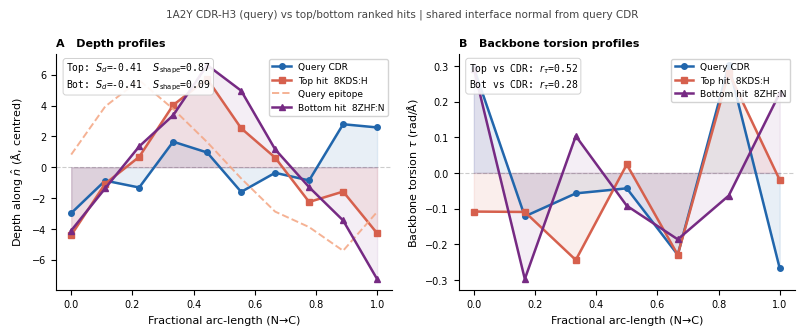

Profiles saved.


In [12]:
# ── shared interface normal from query CDR ────────────────────────────────
_qcdr_ca = query_cdr.ca_coords          # (N, 3)
_qepi_ca = query_epi.coords[:, 1, :]    # (M, 3)
n_hat    = _interface_normal(_qcdr_ca, _qepi_ca)

# depth profiles (projected + mean-centred)
d_qcdr = _qcdr_ca @ n_hat;  d_qcdr -= d_qcdr.mean()
d_epi  = _qepi_ca @ n_hat;  d_epi  -= d_epi.mean()

top = hits[0]
_top_ca = top.superposition.apply(top.fragment.coords)[:, 1, :]
d_top   = _top_ca @ n_hat;  d_top -= d_top.mean()

has_bottom = len(hits) >= 2
if has_bottom:
    bot     = hits[-1]
    _bot_ca = bot.superposition.apply(bot.fragment.coords)[:, 1, :]
    d_bot   = _bot_ca @ n_hat;  d_bot -= d_bot.mean()

# torsion profiles
tau_qcdr = _torsion_profile(_smooth_ca(_qcdr_ca))
tau_top  = _torsion_profile(_smooth_ca(_top_ca))
if has_bottom:
    tau_bot = _torsion_profile(_smooth_ca(_bot_ca))

# common resampling helpers
_Nd = max(len(d_qcdr), len(d_top), len(d_bot) if has_bottom else 0)
_xd = np.linspace(0, 1, _Nd)
def _rd(arr): return np.interp(_xd, np.linspace(0,1,len(arr)), arr)

_Nt = max(len(tau_qcdr), len(tau_top), len(tau_bot) if has_bottom else 0)
_xt = np.linspace(0, 1, _Nt)
def _rt(arr): return np.interp(_xt, np.linspace(0,1,len(arr)), arr)

# print stats
print(f'Top hit : {top.fragment.pdb_id}:{top.fragment.chain}  '
      f'RMSD={top.rmsd_cdr:.3f}  S_shape={top.complementarity_score:.3f}  '
      f'S_final={top.final_score:.4f}')
if has_bottom:
    print(f'Bot hit : {bot.fragment.pdb_id}:{bot.fragment.chain}  '
          f'RMSD={bot.rmsd_cdr:.3f}  S_shape={bot.complementarity_score:.3f}  '
          f'S_final={bot.final_score:.4f}')

# ── figure ────────────────────────────────────────────────────────────────
fig2, (ax_dep, ax_tau) = plt.subplots(1, 2, figsize=(8.0, 3.2))

# — Panel A: depth profiles —
ax_dep.plot(_xd, _rd(d_qcdr), '-o', color=C_CDR,  ms=4, lw=1.8, label='Query CDR')
ax_dep.plot(_xd, _rd(d_top),  '-s', color=C_HIT,  ms=4, lw=1.8,
            label=f'Top hit  {top.fragment.pdb_id}:{top.fragment.chain}')
ax_dep.plot(_xd, _rd(d_epi),  '--', color=C_EPIP, ms=0, lw=1.4, alpha=0.85,
            label='Query epitope')
if has_bottom:
    ax_dep.plot(_xd, _rd(d_bot), '-^', color=C_BOT, ms=4, lw=1.8,
                label=f'Bottom hit  {bot.fragment.pdb_id}:{bot.fragment.chain}')
ax_dep.fill_between(_xd, _rd(d_qcdr), 0, alpha=0.10, color=C_CDR)
ax_dep.fill_between(_xd, _rd(d_top),  0, alpha=0.10, color=C_HIT)
if has_bottom:
    ax_dep.fill_between(_xd, _rd(d_bot), 0, alpha=0.08, color=C_BOT)
ax_dep.axhline(0, color='#cccccc', lw=0.8, ls='--', zorder=0)
ax_dep.text(
    0.03, 0.97,
    f'Top: $S_d$={-_pearson(*_interp_align(d_top, d_epi)):.2f}  '
    f'$S_{{\\mathrm{{shape}}}}$={top.complementarity_score:.2f}\n'
    + (f'Bot: $S_d$={-_pearson(*_interp_align(d_bot, d_epi)):.2f}  '
       f'$S_{{\\mathrm{{shape}}}}$={bot.complementarity_score:.2f}' if has_bottom else ''),
    transform=ax_dep.transAxes, fontsize=7, va='top', family='monospace',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.9, lw=0.7),
)
ax_dep.set_xlabel('Fractional arc-length (N→C)', fontsize=8)
ax_dep.set_ylabel(r'Depth along $\hat{n}$ (Å, centred)', fontsize=8)
ax_dep.legend(fontsize=6.5, loc='upper right', framealpha=0.85, edgecolor='#cccccc')
ax_dep.tick_params(labelsize=7)
ax_dep.set_title('A   Depth profiles', fontsize=8, loc='left', fontweight='bold')

# — Panel B: torsion profiles —
ax_tau.plot(_xt, _rt(tau_qcdr), '-o', color=C_CDR, ms=4, lw=1.8, label='Query CDR')
ax_tau.plot(_xt, _rt(tau_top),  '-s', color=C_HIT, ms=4, lw=1.8,
            label=f'Top hit  {top.fragment.pdb_id}:{top.fragment.chain}')
if has_bottom:
    ax_tau.plot(_xt, _rt(tau_bot), '-^', color=C_BOT, ms=4, lw=1.8,
                label=f'Bottom hit  {bot.fragment.pdb_id}:{bot.fragment.chain}')
ax_tau.fill_between(_xt, _rt(tau_qcdr), 0, alpha=0.10, color=C_CDR)
ax_tau.fill_between(_xt, _rt(tau_top),  0, alpha=0.10, color=C_HIT)
if has_bottom:
    ax_tau.fill_between(_xt, _rt(tau_bot), 0, alpha=0.08, color=C_BOT)
ax_tau.axhline(0, color='#cccccc', lw=0.8, ls='--', zorder=0)
_r_top = _pearson(_rt(tau_top), _rt(tau_qcdr))
ax_tau.text(
    0.03, 0.97,
    f'Top vs CDR: $r_{{\\tau}}$={_r_top:.2f}\n'
    + (f'Bot vs CDR: $r_{{\\tau}}$={_pearson(_rt(tau_bot), _rt(tau_qcdr)):.2f}'
       if has_bottom else ''),
    transform=ax_tau.transAxes, fontsize=7, va='top', family='monospace',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.9, lw=0.7),
)
ax_tau.set_xlabel('Fractional arc-length (N→C)', fontsize=8)
ax_tau.set_ylabel(r'Backbone torsion $\tau$ (rad/Å)', fontsize=8)
ax_tau.legend(fontsize=6.5, loc='upper right', framealpha=0.85, edgecolor='#cccccc')
ax_tau.tick_params(labelsize=7)
ax_tau.set_title('B   Backbone torsion profiles', fontsize=8, loc='left', fontweight='bold')

fig2.suptitle(
    '1A2Y CDR-H3 (query) vs top/bottom ranked hits | shared interface normal from query CDR',
    fontsize=7.5, color='#444444', y=1.01,
)
fig2.tight_layout(pad=0.6, w_pad=1.0)
fig2.savefig(OUT / 'fig_02_profiles.pdf', bbox_inches='tight')
fig2.savefig(OUT / 'fig_02_profiles.png', dpi=200, bbox_inches='tight')
plt.show()
print('Profiles saved.')


## 7 — Panel C: Ranking score distribution

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 8 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'T', 'five', 'nonmarkingreturn', 'o', 'p', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 24, 55, 82, 83]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 8 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'T', 'five', 'nonmarkingreturn', 'o', 'p', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 24, 55, 82, 83]
INFO:fontTools.subset:Closing glyph list over 'glyf': 8 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'T', 'five', 'nonma

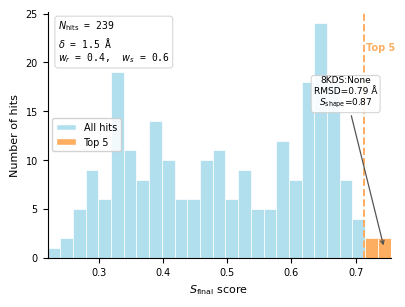

Score distribution saved.


In [13]:
scores      = np.array([h.final_score for h in hits])
n_hits      = len(scores)
top5_thresh = hits[min(4, n_hits-1)].final_score

fig_C, ax_C = plt.subplots(figsize=(4.0, 3.0))

bins = np.linspace(scores.min()-0.01, scores.max()+0.01,
                   max(10, min(28, n_hits+2)))
counts, edges, patches = ax_C.hist(
    scores, bins=bins, color=C_REST, edgecolor='white', linewidth=0.5, zorder=2
)
for patch, left in zip(patches, edges[:-1]):
    if left >= top5_thresh - 1e-6:
        patch.set_facecolor(C_TOP5)
        patch.set_edgecolor('white')

ax_C.axvline(top5_thresh, color=C_TOP5, lw=1.4, ls='--', zorder=3)
ax_C.text(top5_thresh+0.003, counts.max()*0.92,
          'Top 5', fontsize=7, color=C_TOP5, fontweight='bold', va='top')

ax_C.annotate(
    f'{top.fragment.pdb_id}:{top.fragment.cdr_type}\n'
    f'RMSD={top.rmsd_cdr:.2f} Å\n'
    f'$S_{{\\mathrm{{shape}}}}$={top.complementarity_score:.2f}',
    xy=(scores[0], 1.0),
    xytext=(scores[0]-0.06, counts.max()*0.65),
    fontsize=6.5, ha='center',
    arrowprops=dict(arrowstyle='->', color='#555', lw=0.9),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.9, lw=0.7),
)

ax_C.text(0.03, 0.97,
          f'$N_{{\\mathrm{{hits}}}}$ = {n_hits}\n'
          f'$\\delta$ = 1.5 Å\n'
          f'$w_r$ = 0.4,  $w_s$ = 0.6',
          transform=ax_C.transAxes, fontsize=7, va='top', family='monospace',
          bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.9, lw=0.7))

ax_C.set_xlabel(r'$S_{\mathrm{final}}$ score', fontsize=8)
ax_C.set_ylabel('Number of hits', fontsize=8)
ax_C.tick_params(labelsize=7)
ax_C.set_xlim(edges[0], edges[-1])
ax_C.legend(
    handles=[
        Patch(facecolor=C_REST, edgecolor='white', label='All hits'),
        Patch(facecolor=C_TOP5, edgecolor='white', label='Top 5'),
    ],
    fontsize=7, loc='center left', framealpha=0.85, edgecolor='#cccccc',
)

fig_C.tight_layout(pad=0.5)
fig_C.savefig(OUT / 'fig_03_score_distribution.pdf', bbox_inches='tight')
fig_C.savefig(OUT / 'fig_03_score_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print('Score distribution saved.')


## 9 — Hit summary table (detailed)


In [14]:
import pandas as pd

rows = []
for i, h in enumerate(hits[:15], 1):
    rows.append({
        'Rank'     : i,
        'PDB:chain': f'{h.fragment.pdb_id}:{h.fragment.chain}',
        'Residues' : f'{h.fragment.residue_range[0]}-{h.fragment.residue_range[1]}',
        'Sequence' : h.fragment.sequence,
        'RMSD (A)' : round(h.rmsd_cdr, 3),
        'S_shape'  : round(h.complementarity_score, 3),
        'S_final'  : round(h.final_score, 4),
    })

df = pd.DataFrame(rows).set_index('Rank')
df.to_csv(OUT / 'hits_summary.csv')

display(
    df.style
      .background_gradient(subset=['S_final'], cmap='RdYlGn', vmin=0, vmax=1)
      .background_gradient(subset=['RMSD (A)'], cmap='RdYlGn_r', vmin=0, vmax=2)
      .format({'RMSD (A)': '{:.3f}', 'S_shape': '{:.3f}', 'S_final': '{:.4f}'})
      .set_caption(
          f'Top-15 EpiFitScout hits | query = 1A2Y CDR-H3 | '
          f'N = {n_hits} hits | delta = 1.5 A'
      )
)

print('\nOutput files:')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name:<40}  {f.stat().st_size // 1024} KB')


INFO:numexpr.utils:Note: detected 256 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 256 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


,PDB:chain,Residues,Sequence,RMSD (A),S_shape,S_final
Rank,,,,,,
1,8KDS:H,148-157,QWKVDNALQS,0.791,0.869,0.7445
2,8KER:H,148-157,QWKVDNALQS,0.673,0.834,0.7392
3,8KEO:F,148-157,QWKVDNALQS,0.783,0.837,0.7266
4,8UKH:H,172-181,AVLQSDLYTL,0.797,0.826,0.7181
5,8RTW:C,147-156,KWKIDGSERQ,0.815,0.821,0.7130
6,8VYN:O,90-99,GTWDDNSWVF,1.008,0.833,0.6993
7,8VYM:F,90-99,GTWDDNSWVF,1.093,0.847,0.6991
8,8ZHK:F,151-160,AWKADSSPVK,0.895,0.810,0.6971
9,8S4K:H,165-174,AVLQSDLYTL,0.827,0.792,0.6943



Output files:
  fig_02_profiles.pdf                       38 KB
  fig_02_profiles.png                       193 KB
  fig_03_score_distribution.pdf             28 KB
  fig_03_score_distribution.png             39 KB
  hits_summary.csv                          0 KB
